In [428]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from scipy.stats import ttest_rel

In [430]:
df = pd.read_csv(r'C:\Users\Hena\Desktop\Pilot Survey Data\Final Accommodation Survey Data.csv', encoding='ISO-8859-1')

In [434]:
df.head()

,No.,Hotel Name,Northing,Easting,Number of years,Number of Bedrooms,Number of Employees,Gross floor Area (m2),Quantity of FP (ton/Year),Quantity of FA (ton/Year)
0,1,Keba Guest house,"9° 1' 28.370"" N","38° 47' 26.059"" E",14,30,43,5600,533.0,364.0
1,2,Mad vervet hostel Addis,"9° 0' 29.588"" N","38° 48' 1.400"" E",16,20,20,3900,390.0,260.0
2,3,Wib Guest House,"9° 1' 13.288"" N","38° 47' 37.507"" E",25,22,26,4500,429.0,286.0
3,4,Ag Palace Hotel,"9° 1' 5.886"" N","38° 47' 28.735"" E",16,19,20,3850,390.0,260.0
4,5,Glam Hotel,"9° 1' 49.568"" N","38° 45' 39.313"" E",12,25,30,4700,468.0,312.0


In [432]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   No.                        277 non-null    int64  
 1   Hotel Name                 277 non-null    object 
 2   Northing                   277 non-null    object 
 3   Easting                    277 non-null    object 
 4   Number of years            277 non-null    int64  
 5   Number of Bedrooms         277 non-null    int64  
 6   Number of Employees        277 non-null    int64  
 7   Gross floor Area  (m2)     277 non-null    int64  
 8   Quantity of FP (ton/Year)  277 non-null    float64
 9   Quantity of FA (ton/Year)  277 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 21.8+ KB


In [436]:
df.describe()

,No.,Number of years,Number of Bedrooms,Number of Employees,Gross floor Area (m2),Quantity of FP (ton/Year),Quantity of FA (ton/Year)
count,277.00000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000
mean,139.00000,11.718412,36.527076,42.696751,6454.747292,710.044043,476.053430
std,80.10722,6.098835,66.716278,46.101594,6366.396264,765.468097,528.466109
min,1.00000,2.000000,2.000000,4.000000,460.000000,62.400000,41.600000
25%,70.00000,8.000000,13.000000,10.000000,2900.000000,312.000000,208.000000
50%,139.00000,11.000000,27.000000,31.000000,5000.000000,468.000000,312.000000
75%,208.00000,14.000000,43.000000,56.000000,7900.000000,780.000000,520.000000
max,277.00000,76.000000,1024.000000,392.000000,64000.000000,6994.000000,5200.000000


In [438]:
df = df.drop(columns=df.select_dtypes(include='object').columns)
df = df.drop(columns=['No.', 'Number of Bedrooms'])

In [440]:
df.isnull().sum()

Number of years              0
Number of Employees          0
Gross floor Area  (m2)       0
Quantity of FP (ton/Year)    0
Quantity of FA (ton/Year)    0
dtype: int64

In [442]:
df.duplicated().sum()

0

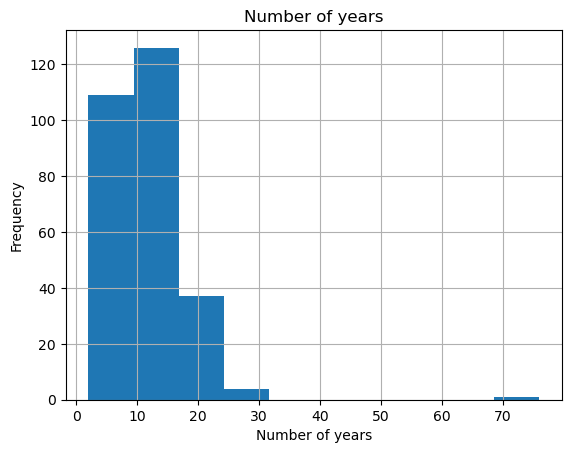

In [444]:
col = df.columns[0]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Accomodation Report/first_column_hist.png')

plt.show()

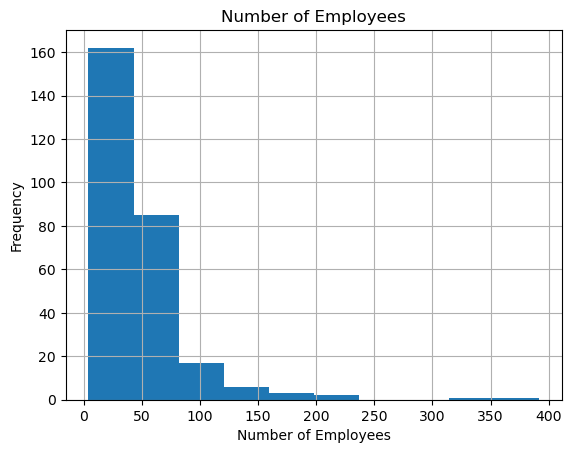

In [445]:
col = df.columns[1]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Accomodation Report/second_column_hist.png')

plt.show()

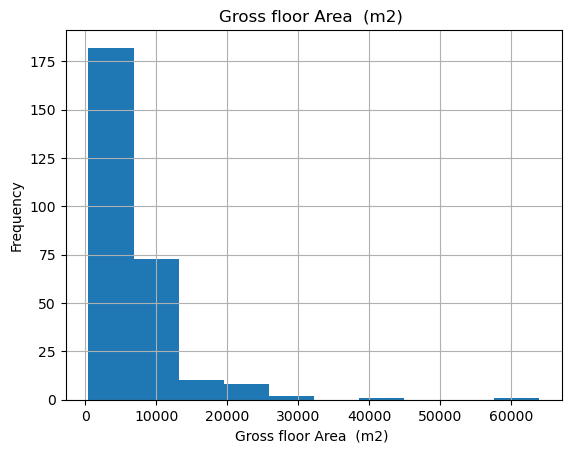

In [446]:
col = df.columns[2]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Accomodation Report/third_column_hist.png')

plt.show()

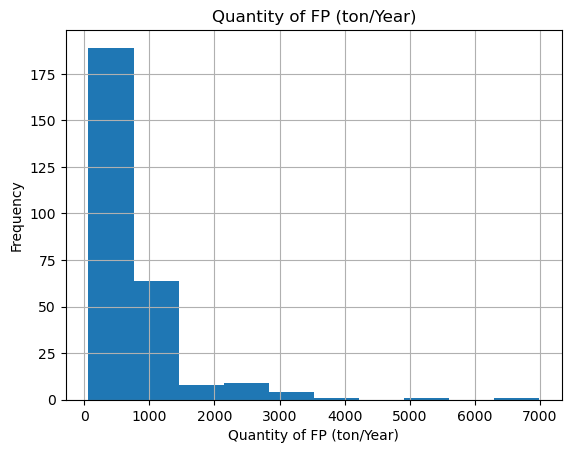

In [448]:
col = df.columns[3]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Accomodation Report/fourth_column_hist.png')

plt.show()

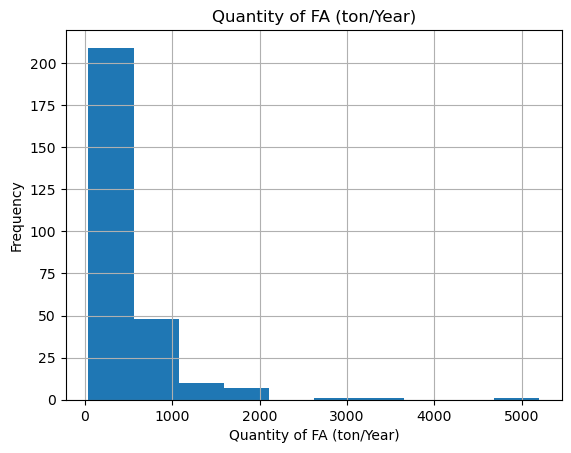

In [449]:
col = df.columns[4]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Accomodation Report/fifth_column_hist.png')

plt.show()

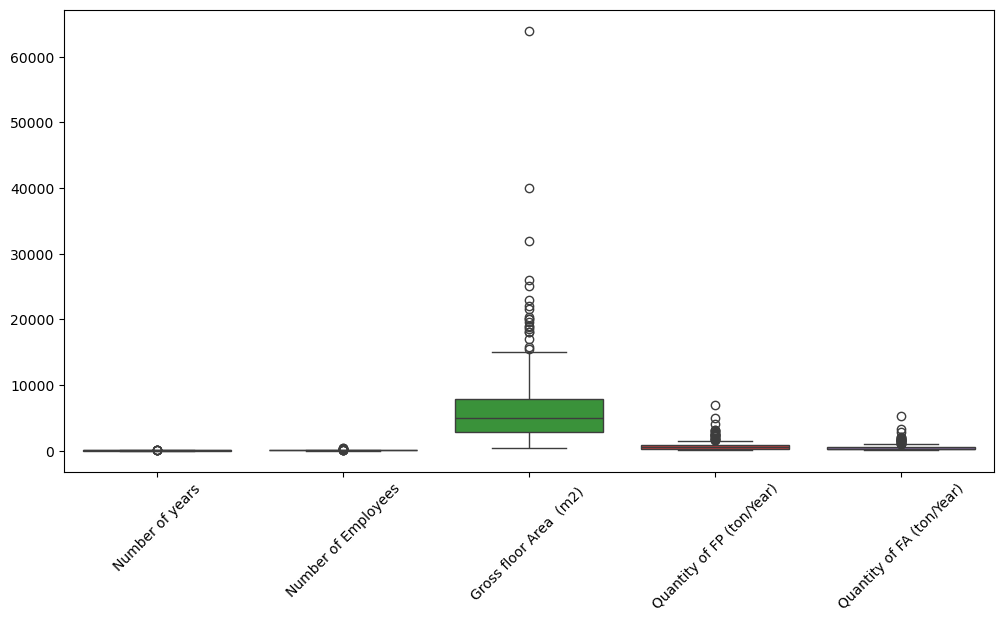

In [450]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
# Save the figure
plt.savefig('Desktop/Accomodation Report/Distrbution,Variability,outlier_column_hist.png')
plt.show()

In [452]:
df1 = df.drop(columns=[ 'Quantity of FA (ton/Year)'])

In [453]:
df2 = df.drop(columns=[ 'Quantity of FP (ton/Year)'])

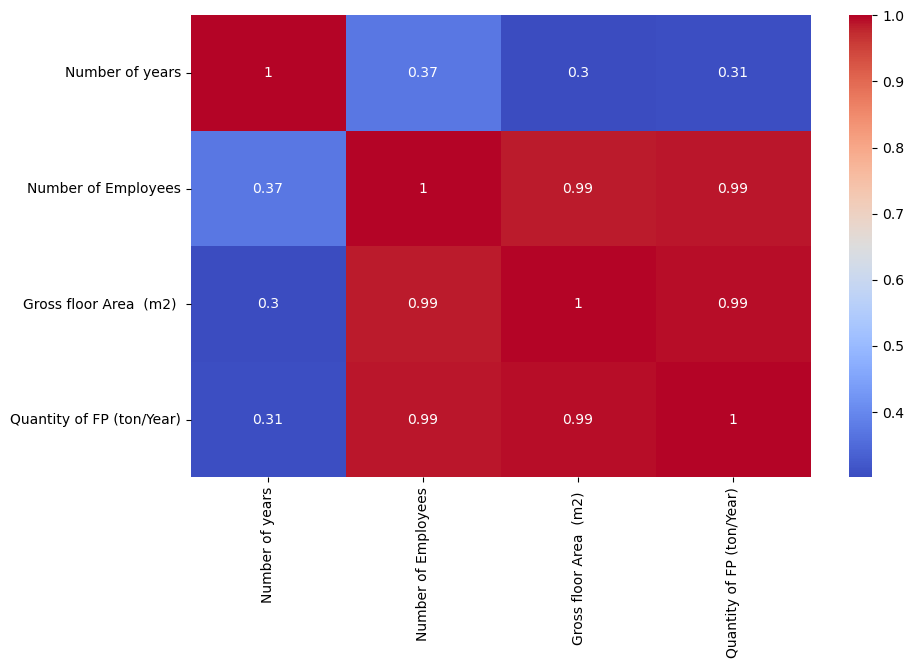

In [454]:
corr = df1.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig('Desktop/Accomodation Report/FP_Corr.png')

plt.show()

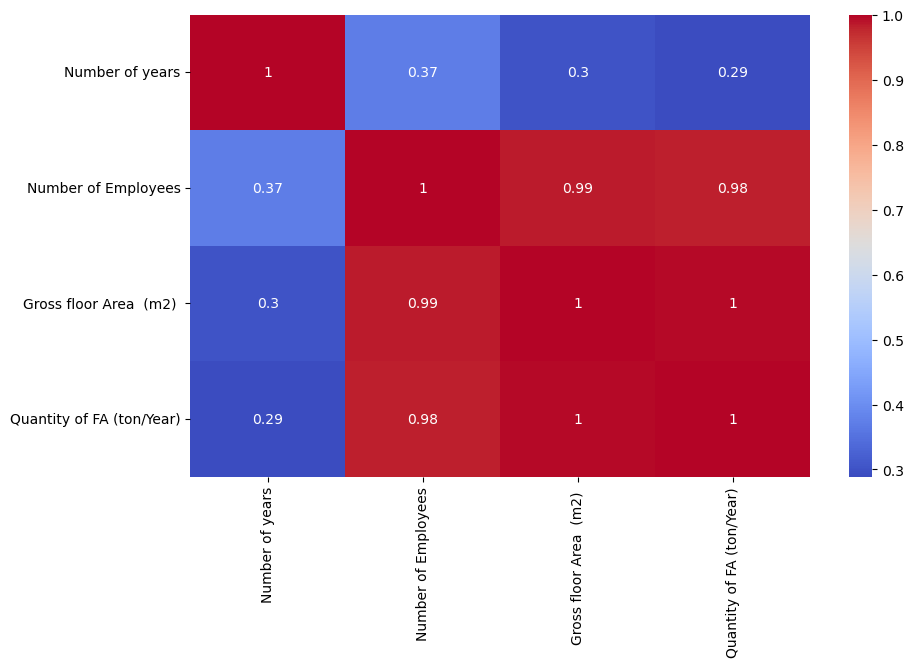

In [456]:
corr = df2.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig('Desktop/Accomodation Report/FA_Corr.png')

plt.show()

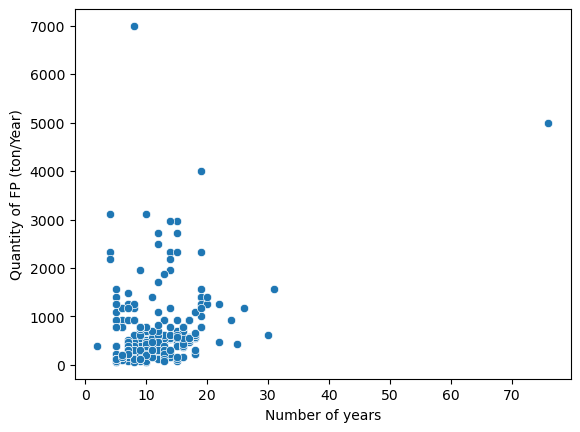

In [458]:
sns.scatterplot(x='Number of years', y='Quantity of FP (ton/Year)', data=df1)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FPvsNo.years_column_hist.png')

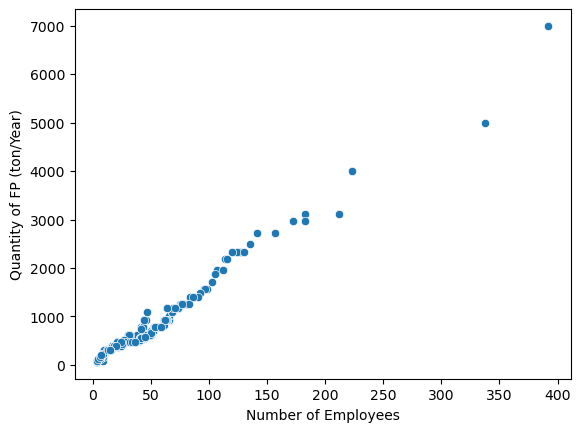

In [459]:
sns.scatterplot(x='Number of Employees', y='Quantity of FP (ton/Year)', data=df1)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FPvsNo.Employees_column_hist.png')

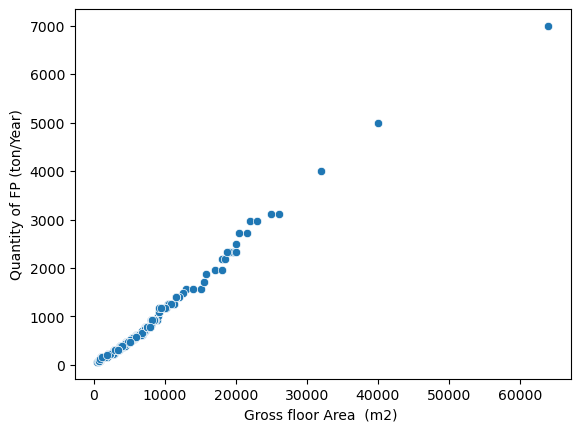

In [461]:
sns.scatterplot(x='Gross floor Area  (m2) ', y='Quantity of FP (ton/Year)', data=df1)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FPvsNo.GFA_column_hist.png')

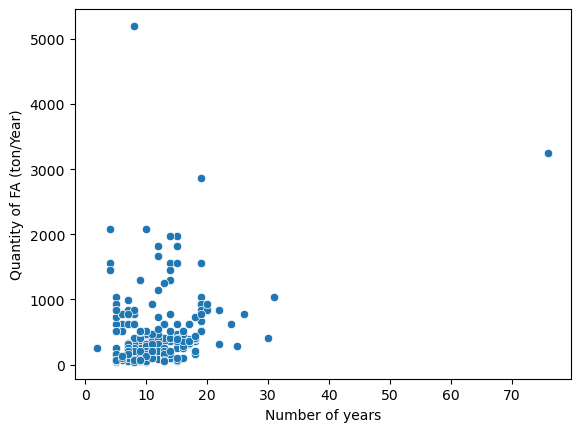

In [463]:
sns.scatterplot(x='Number of years', y='Quantity of FA (ton/Year)', data=df2)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FAvsNo.years_column_hist.png')

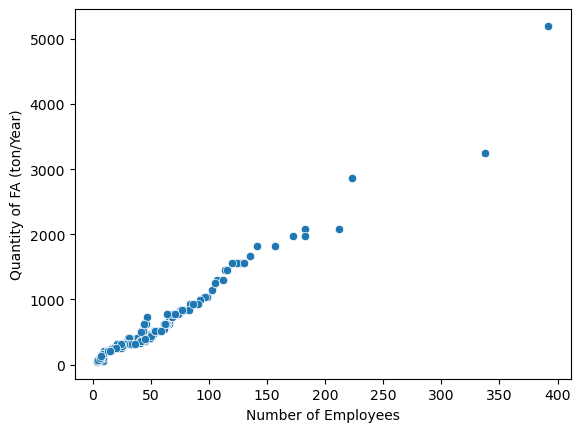

In [466]:
sns.scatterplot(x='Number of Employees', y='Quantity of FA (ton/Year)', data=df2)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FAvsNo.Employees_column_hist.png')

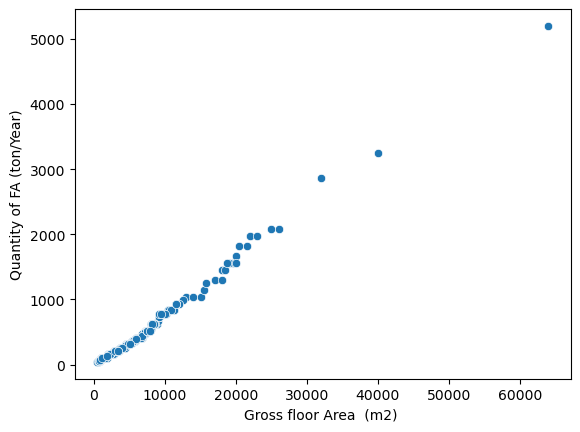

In [468]:
sns.scatterplot(x='Gross floor Area  (m2) ', y='Quantity of FA (ton/Year)', data=df2)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FAvsNo.GFA_column_hist.png')

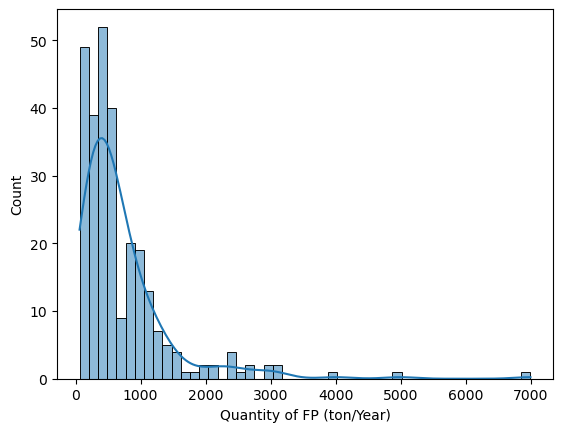

In [469]:
sns.histplot(df1['Quantity of FP (ton/Year)'], kde=True)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FPvsCount_column_hist.png')

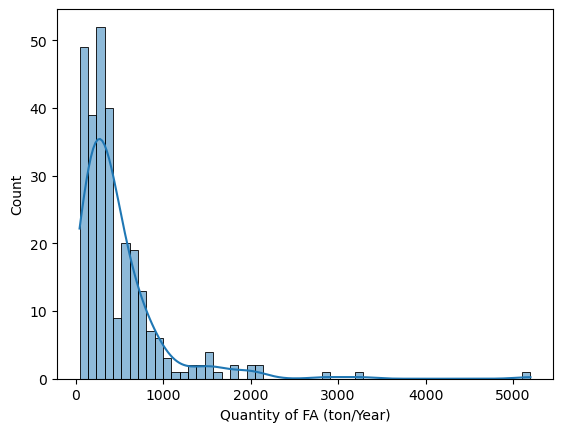

In [471]:
sns.histplot(df2['Quantity of FA (ton/Year)'], kde=True)
# Save the figure
plt.savefig('Desktop/Accomodation Report/FAvsCount_column_hist.png')

In [472]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number of years            277 non-null    int64  
 1   Number of Employees        277 non-null    int64  
 2   Gross floor Area  (m2)     277 non-null    int64  
 3   Quantity of FP (ton/Year)  277 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 8.8 KB


In [475]:
X = df1.drop(columns=['Quantity of FP (ton/Year)'])
y = df1['Quantity of FP (ton/Year)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [479]:
X_train.shape

(221, 3)

In [481]:
X_test.shape

(56, 3)

In [483]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 259 to 102
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Number of years          221 non-null    int64
 1   Number of Employees      221 non-null    int64
 2   Gross floor Area  (m2)   221 non-null    int64
dtypes: int64(3)
memory usage: 6.9 KB


In [490]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

In [492]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
print("R2:", r2_score(y_test, y_pred_lr))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

# ✅ Full regression summary
print("\nOLS Regression Summary:")
print(ols_model.summary())

MAE: 49.743605476482394
RMSE: 62.79170501883293
R2: 0.9908046518503559
Intercept: -28.949547246429688

Coefficients with P-values and Significance Level:
Number of years: Coef = -1.532, P-value = 0.135, Significance ≈ 86.5%
Number of Employees: Coef = 4.780, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.085, P-value = 0.000, Significance ≈ 100.0%

OLS Regression Summary:
                                OLS Regression Results                               
Dep. Variable:     Quantity of FP (ton/Year)   R-squared:                       0.990
Model:                                   OLS   Adj. R-squared:                  0.990
Method:                        Least Squares   F-statistic:                     7425.
Date:                       Tue, 16 Jun 2026   Prob (F-statistic):          2.40e-218
Time:                               13:22:28   Log-Likelihood:                -1275.0
No. Observations:                        221   AIC:                             2558.

C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_25252\2797349557.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_25252\2797349557.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_25252\2797349557.py:14: FutureWarn

In [510]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number of years            277 non-null    int64  
 1   Number of Employees        277 non-null    int64  
 2   Gross floor Area  (m2)     277 non-null    int64  
 3   Quantity of FA (ton/Year)  277 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 8.8 KB


In [512]:
X = df2.drop(columns=['Quantity of FA (ton/Year)'])
y = df2['Quantity of FA (ton/Year)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [514]:
X_train.shape

(221, 3)

In [516]:
X_test.shape

(56, 3)

In [518]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 259 to 102
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Number of years          221 non-null    int64
 1   Number of Employees      221 non-null    int64
 2   Gross floor Area  (m2)   221 non-null    int64
dtypes: int64(3)
memory usage: 6.9 KB


In [520]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

In [524]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
print("R2:", r2_score(y_test, y_pred_lr))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

# ✅ Full regression summary
print("\nOLS Regression Summary:")
print(ols_model.summary())

MAE: 29.9676398083651
RMSE: 38.57126414834168
R2: 0.9921851231488233
Intercept: -40.188343723531034

Coefficients with P-values and Significance Level:
Number of years: Coef = -1.547, P-value = 0.019, Significance ≈ 98.1%
Number of Employees: Coef = 0.950, P-value = 0.044, Significance ≈ 95.6%
Gross floor Area (m2): Coef = 0.077, P-value = 0.000, Significance ≈ 100.0%

OLS Regression Summary:
                                OLS Regression Results                               
Dep. Variable:     Quantity of FA (ton/Year)   R-squared:                       0.992
Model:                                   OLS   Adj. R-squared:                  0.992
Method:                        Least Squares   F-statistic:                     8782.
Date:                       Tue, 16 Jun 2026   Prob (F-statistic):          3.48e-226
Time:                               13:29:28   Log-Likelihood:                -1176.1
No. Observations:                        221   AIC:                             2360.
Df

C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_25252\2797349557.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_25252\2797349557.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_25252\2797349557.py:14: FutureWarn